# iq simple #

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
#from scipy.fft import fft, ifft, fftfreq

fs = 4.096000e+07


Text(0.5, 1.0, 'Baseband signal')

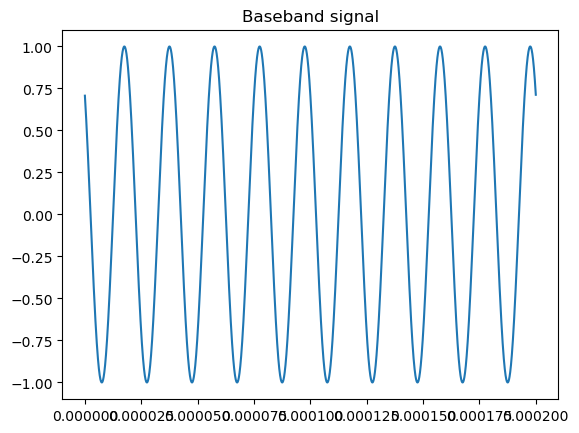

In [2]:
A_bb = 1
f_bb = 50e3 # 50kHz
phi_bb = np.pi/4
N=4096*2;  # number sample points

f_s = 40.96e6
print(f'fs = {f_s:e}')

# Generate some baseband data

t = np.arange(N)/f_s
bb = np.cos(2*np.pi*f_bb*t + phi_bb)   # some_signal
plt.plot(t,bb)
plt.title("Baseband signal")

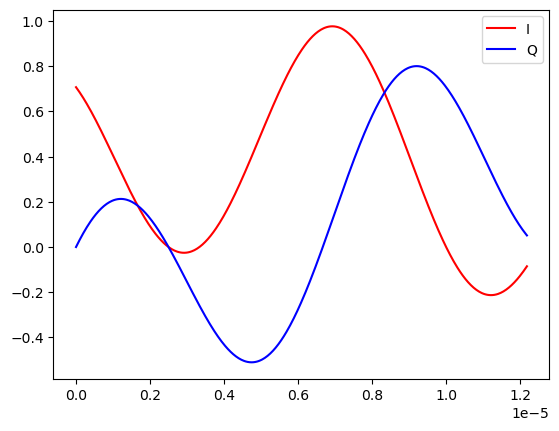

In [3]:
f_c = 1.5*f_bb
lo_cos = np.cos(2*np.pi*t*f_c)
lo_sin = np.sin(2*np.pi*t*f_c)

I = bb * lo_cos
Q = bb * lo_sin

fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.plot(t[:500], I[:500], c='r', label = "I")
ax1.plot(t[:500], Q[:500], c='b', label = "Q")
plt.legend(loc='upper right')
plt.show()

We now compare the FFT's of the input signal vs I and Q

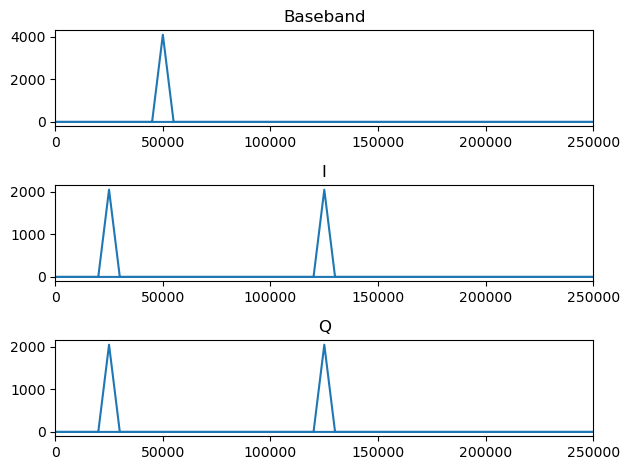

In [5]:
X_bb = np.fft.fft(bb, N)
X_I = np.fft.fft(I, N)
X_Q = np.fft.fft(I, N)

freqs = np.fft.fftfreq(N,1/f_s) # Get the corresponding frequencies

fig, ax = plt.subplots(3,1)
ax[0].plot(freqs, np.abs(X_bb))
ax[0].set_title("Baseband")
ax[1].plot(freqs, np.abs(X_I))
ax[1].set_title("I")
ax[2].plot(freqs, np.abs(X_Q))
ax[2].set_title("Q")

ax[0].set_xlim([0,2*(f_bb+f_c)])
ax[1].set_xlim([0,2*(f_bb+f_c)])
ax[2].set_xlim([0,2*(f_bb+f_c)])

plt.tight_layout()
